# Prediksi Harga Pangan

Proyek ini bertujuan untuk memprediksi harga pangan menggunakan model Machine Learning.

Dataset:
- Provinsi: Jawa Timur
- Komoditas: Beras

Pipeline yang dilakukan:
1. Load dataset
2. Train-test split
3. Model training
4. Model evaluation
5. Visualisasi Actual vs Predicted

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# Load dataset

In [2]:
df = pd.read_csv("../data/processed/harga_features.csv")

df["Tanggal"] = pd.to_datetime(df["Tanggal"])

df.head()

,Tanggal,Provinsi,Komoditas,Nilai,NilaiDiff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2024-03-01,Sulawesi Tengah,Beras,15650.0,Rp0,14800.0,13800.0,14778.571429,748.251931
1,2024-03-01,Jambi,Beras,14800.0,Rp0,15650.0,15850.0,14628.571429,585.133277
2,2024-03-01,DI Yogyakarta,Beras,15400.0,Rp0,14800.0,13850.0,14850.000000,532.290647
3,2024-03-01,Jawa Timur,Beras,15400.0,Rp0,15400.0,14050.0,15042.857143,428.591269
4,2024-03-01,Riau,Beras,15450.0,Rp100,15400.0,14550.0,15171.428571,389.291175


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17600 entries, 0 to 17599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanggal         17600 non-null  datetime64[ns]
 1   Provinsi        17600 non-null  object        
 2   Komoditas       17600 non-null  object        
 3   Nilai           17600 non-null  float64       
 4   NilaiDiff       17600 non-null  object        
 5   lag_1           17600 non-null  float64       
 6   lag_7           17600 non-null  float64       
 7   rolling_mean_7  17600 non-null  float64       
 8   rolling_std_7   17600 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 1.2+ MB


# Train Test Split 
80% data untuk training dan 20% untuk testing.

In [4]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 14080
Test size: 3520


# Menentukan feature dan target

In [5]:
features = ["lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]

X_train = train[features]
y_train = train["Nilai"]

X_test = test[features]
y_test = test["Nilai"]

# Baseline Model
Pakai Linear regresion karena cepat dilatih, mudah dipahami, mudah debugging jadi memudahkan untuk menemukan kesalahan dan membentuk baseline model awal sebelum di produksinya

Model produksi -> XGBoost karena bisa menangkap pola non linear, lebih tahan terhadap noise

# Training Model

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Evaluasi Model

In [7]:
mape = mean_absolute_percentage_error(y_test, predictions)

print("MAPE:", mape)

MAPE: 0.03650339941838848


# Dataset Hasil Prediksi

In [8]:
result = test.copy()

result["Predicted"] = predictions

result.head()

,Tanggal,Provinsi,Komoditas,Nilai,NilaiDiff,lag_1,lag_7,rolling_mean_7,rolling_std_7,Predicted
14080,2025-10-07,Kalimantan Tengah,Beras,17500.0,Rp0,17450.0,16550.0,17378.571429,753.246940,17326.969460
14081,2025-10-07,Sulawesi Tenggara,Beras,16000.0,Rp0,17500.0,18900.0,16964.285714,545.980987,16836.503643
14082,2025-10-07,Papua Barat,Beras,16900.0,Rp0,16000.0,16500.0,17021.428571,508.967208,16845.425091
14083,2025-10-08,Sumatera Utara,Beras,14600.0,-Rp50,16900.0,16950.0,16685.714286,1050.680052,16404.877683
14084,2025-10-08,Sulawesi Barat,Beras,14650.0,Rp0,14600.0,17050.0,16342.857143,1278.810832,15400.025515


Interpretasi:

Model menggunakan harga masa lalu (lag features) untuk memprediksi harga.

Prediksi berada di sekitar nilai aktual, tidak terlalu jauh.

Perbedaan kecil ini yang dihitung oleh MAPE.

# Visualisasi Harga Actual vs Predicted

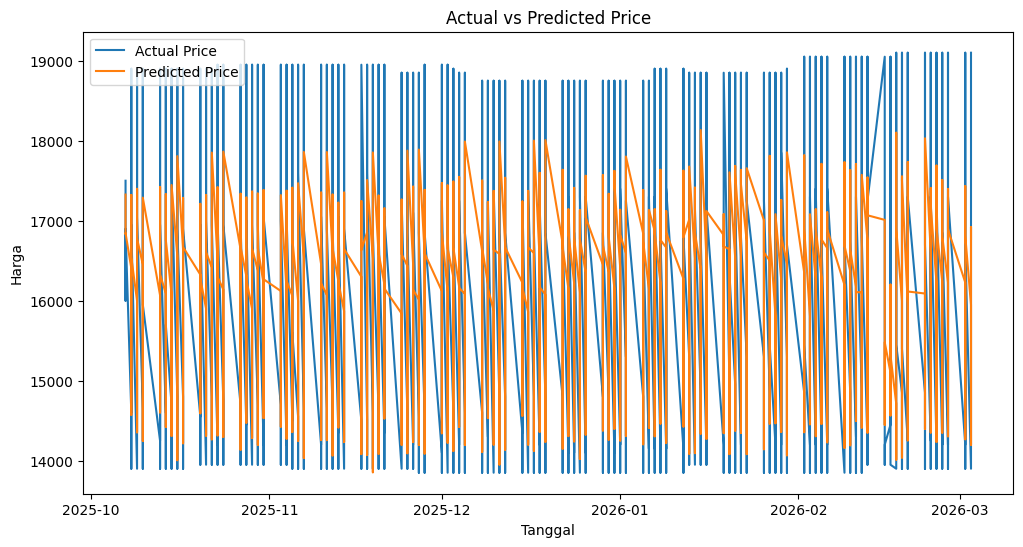

In [9]:
plt.figure(figsize=(12,6))

plt.plot(result["Tanggal"], result["Nilai"], label="Actual Price")

plt.plot(result["Tanggal"], result["Predicted"], label="Predicted Price")

plt.xlabel("Tanggal")
plt.ylabel("Harga")

plt.title("Actual vs Predicted Price")

plt.legend()

plt.show()

a. Model Mengikuti Pola Umum Harga

Garis prediksi sebagian besar mengikuti arah garis aktual, artinya model mampu menangkap trend perubahan harga.

b. Ada Selisih pada Beberapa Titik

Pada beberapa tanggal terlihat jarak antara dua garis.

Ini normal karena:

model tidak mengetahui masa depan

harga pangan memiliki fluktuasi yang cukup tinggi

c. Prediksi Cenderung Lebih Halus

Garis prediksi biasanya lebih smooth karena model belajar pola rata-rata dari data historis.